In [1]:
import sys
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np
sys.path.append("/Users/gabriel/Desktop/Quant_Project/Quant-Summer-Project")
from scipy.stats import norm
from tests.fixtures.synthetic_data import synthetic_actual_df, synthetic_previous_df
from data import fetcher
from data.fetcher import (
fetch_data,
get_tommorows_wheather,
pair_dataframes,compute_forecast_error,
fetch_previous_forecast_data,
get_daily_max,
call_fetcher_functions,
)
from evaluation.calibration import (
get_guessed_prob,
calculate_buckets,

)

from models.bayesian_model import (
bayesian_interference,
posterior_probability,
)

from models.baseline import (
gaussian_probability
)
from models.kde_model import (
kde_estimate
)
from data.cleaner import clean_data
from data.loader import (
add_event_column,
filter_summer
)
from config.settings import (
HISTORICAL_START,
HISTORICAL_END,
DEFAULT_CITY,
TOMMORROWS_DATE,
FORECAST_START,
FORECAST_END,
LOWER_BOUND,
UPPER_BOUND,
IS_START,
IS_END,
OOS_START,
OOS_END,
)

from evaluation.eval_loop import (
run_eval,
)
from evaluation.scoring import (
brier_score,
log_loss,
skill_score
)
from pricing.fair_value import ( 
create_buckets,
build_probability_vector,
find_correct_bucket,

)
from models import baseline
from models.bayesian_model import posterior_probability
from models.kde_model import kde_estimate
from data import fetcher, cleaner, loader
from config import settings

fetcher.fetch_data = lambda *args, **kwargs: synthetic_actual_df()
fetcher.fetch_previous_forecast_data = lambda *args, **kwargs: synthetic_previous_df()

 Total days this experiment ran on:  10
Gauss
{0: 70, 1: 20, 2: 10, 3: 10}
KDE
{0: 70, 1: 20, 2: 20}
Bayes
{0: 100, 9: 10}


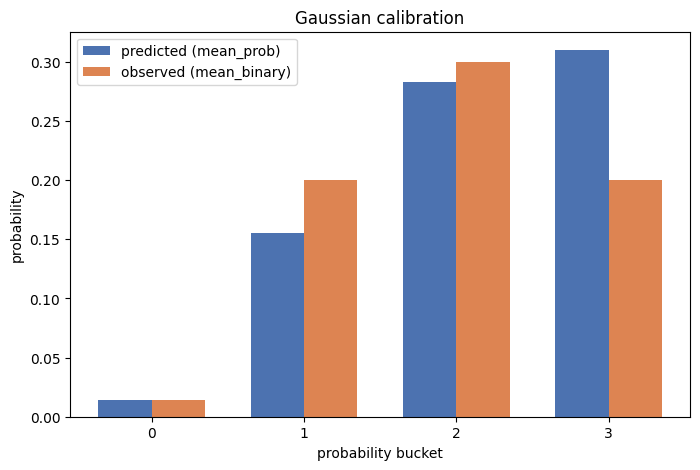

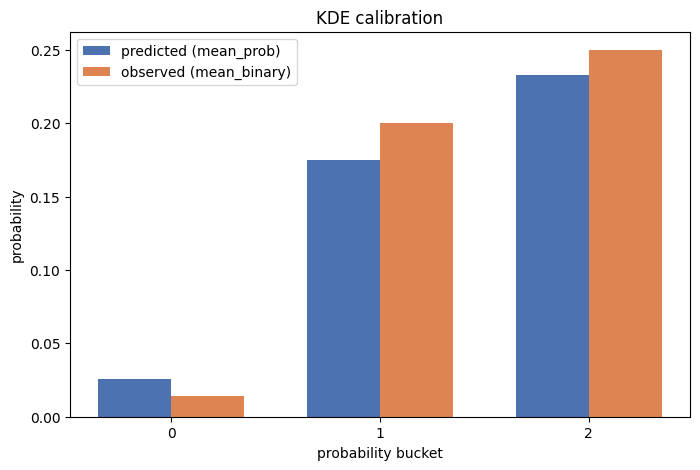

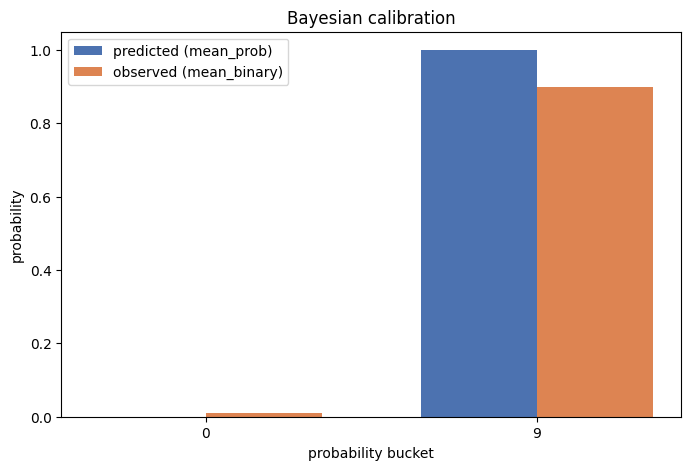

In [2]:
fetcher.get_tommorows_wheather = lambda *args, **kwargs: 30

df_raw = fetcher.fetch_data(IS_START,IS_END)
df_clean = cleaner.clean_data(df_raw)
df_event = loader.add_event_column(df_clean)
df_temp_summer = loader.filter_summer(df_event)
df_summer = df_temp_summer["temperature_2m_max"].to_list()

df_pair = fetcher.call_fetcher_functions(OOS_START, OOS_END)

buckets = create_buckets(25, 36)


gaussian_prob_fn = lambda low, high: baseline.gaussian_probability(df_summer, low, high)[0]
kde_prob_fn = lambda low, high: kde_estimate(df_summer, low, high)

bayesian_factory = lambda day: (lambda low, high: posterior_probability(df_summer, day, df_pair, low, high))

sample_vector = build_probability_vector(gaussian_prob_fn, buckets)
sample_index = find_correct_bucket(df_pair["actual_temp"].to_list()[0], buckets)


prob_matrix_gauss, correct_indices_gauss = run_eval(lambda day: gaussian_prob_fn, buckets, df_pair)
prob_matrix_kde, correct_indices_kde = run_eval(lambda day: kde_prob_fn, buckets, df_pair)
prob_matrix_bayes, correct_indices_bayes = run_eval(bayesian_factory, buckets, df_pair)






guessed_prob_gauss = get_guessed_prob(prob_matrix_gauss,correct_indices_gauss)
guessed_prob_kde = get_guessed_prob(prob_matrix_kde,correct_indices_kde)
guessed_prob_bayes = get_guessed_prob(prob_matrix_bayes,correct_indices_bayes)


print(f" Total days this experiment ran on:  {len(correct_indices_gauss)}")


print("Gauss")
data_gauss = calculate_buckets(guessed_prob_gauss)


print("KDE")
data_kde = calculate_buckets(guessed_prob_kde)


print("Bayes")
data_bayes = calculate_buckets(guessed_prob_bayes)





def plot_calibration(data, title):
    buckets = [row[0] for row in data]
    mean_probs = [row[1] for row in data]
    mean_binaries = [row[2] for row in data]
    x = np.arange(len(buckets))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, mean_probs, width, label="predicted (mean_prob)", color="#4C72B0")
    ax.bar(x + width/2, mean_binaries, width, label="observed (mean_binary)", color="#DD8452")

    ax.set_xlabel("probability bucket")
    ax.set_ylabel("probability")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(buckets)
    ax.legend()
    plt.show()

plot_calibration(data_gauss, "Gaussian calibration")
plot_calibration(data_kde, "KDE calibration")
plot_calibration(data_bayes, "Bayesian calibration")



Results: 
GAUSS
0 mean_prob: 0.028 mean_binary: 0.061
1 mean_prob: 0.161 mean_binary: 0.122
2 mean_prob: 0.242 mean_binary: 0.163
KDE
0 mean_prob: 0.028 mean_binary: 0.061
1 mean_prob: 0.159 mean_binary: 0.122
2 mean_prob: 0.243 mean_binary: 0.163
BAYES
0 mean_prob: 0.011 mean_binary: 0.02
1 mean_prob: 0.148 mean_binary: 0.183
2 mean_prob: 0.251 mean_binary: 0.237
3 mean_prob: 0.358 mean_binary: 0.301
4 mean_prob: 0.405 mean_binary: 0.363


While the Brier and log-loss scores show Bayesian has lower error, calibration answers a different question: when a model says a bucket has a given probability, does that actually happen that often? For this, every (day, bucket) prediction across all three models was binned by its predicted probability, and each bin's average prediction was compared against how often that bucket actually occurred.

One notable finding: across the entire dataset, no model — including Bayesian — ever assigned a confidence above roughly 40-49% to any single 1°C bucket. Even with a forecast tightening the distribution, real forecast uncertainty (sigma_forecast ≈ 1.18°C) still spreads meaningful probability across 2-3 adjacent buckets rather than collapsing onto one. None of these models ever become "very sure" in an absolute sense.

Gaussian and KDE show an inconsistent calibration pattern: underconfident in the lowest bin (predicting ~2.8% when the event happened ~6.1% of the time), but overconfident in the middle bins (predicting ~24.2% when it happened ~16.3% of the time). This inconsistency — flipping direction between bins — is itself evidence of miscalibration, separate from how much data sits in each bin.

Bayesian, by contrast, is reasonably well-calibrated overall. Its gaps in the low bins are smaller than Gaussian/KDE's (roughly 0.01-0.035 vs. 0.04-0.08), and even its higher bins (3-4), where it shows mild overconfidence (predicting ~36-40% against an observed ~30-36%), the gap stays moderate rather than extreme. So the fair conclusion isn't "Bayesian is miscalibrated" — it's that Bayesian earns its lower error and is roughly as trustworthy probability-for-probability, with a mild overconfidence trend only at its highest-confidence predictions.

One caveat still to check: how many (day, bucket) pairs actually land in those higher bins (3-4) for Bayesian. If very few predictions reach that range, the overconfidence estimate there is noisier and less conclusive than the lower bins.
